# Godiva Benchmark Tutorial

This notebook demonstrates how to model the **Lady Godiva assembly** a simple, bare sphere of highly enriched uranium using the OpenMC Python API. This serves as a barebone working example to show how OpenMC works. 

## What is Godiva?
The Lady Godiva reactor was an experimental pulse reactor operated at Los Alamos National Laboratory in the 1950s. It was designed to study the behavior of a "naked" (unreflected) fast-neutron system. Because it has no complex cooling pipes, shielding, or moderators, it is the perfect benchmark for testing the accuracy of nuclear data and simulation codes.
Key Characteristics:
- A simple, solid sphere of metal with a radius of approximately 8.74 cm.
- Highly Enriched Uranium (HEU) at roughly 94% enrichment.
- It consists of only three nuclides: $U^{234}$, $U^{235}$, and $U^{238}$.

![Godiva Assembly](https://upload.wikimedia.org/wikipedia/commons/2/2a/Godiva-before-scrammed.jpg)

### The OpenMC Workflow
OpenMC's simulation engine is written in C++. It does not read Python code directly. Instead, it looks for **XML files** in your working directory to understand the model. 

The Python API we use here is a convenient way to generate these files:
1. **`materials.xml`**: Defines the isotopes.
2. **`geometry.xml`**: Defines the shapes and boundaries.
3. **`settings.xml`**: Defines how the simulation runs (particle count, batches).
4. **`tallies.xml`**: (Optional) Defines what data we want to collect.

In [1]:
import openmc
import openmc_data_downloader as odd

## 1. Materials
**Materials** define *what* the objects in your simulation are made of. 

In OpenMC, you define a material by adding specific **nuclides** (isotopes), setting a **density**, and optionally assigning an **ID** or **temperature**. For Godiva, we use Highly Enriched Uranium (HEU).

In [2]:
heu = openmc.Material(1, "heu")
heu.set_density('atom/b-cm', 0.047984)
heu.add_nuclide('U234', 1.025003e-02)
heu.add_nuclide('U235', 9.376829e-01)
heu.add_nuclide('U238', 5.206710e-02)

materials = openmc.Materials([heu])
materials.export_to_xml()
print("materials.xml has been created.")

materials.xml has been created.


### Nuclear Data
OpenMC needs "cross-section" data to know how neutrons interact with atoms. We use a downloader to ensure the simulation has access to these files. 

In [ ]:
# Not needed if you already have the cross-section data.
odd.download_cross_section_data(
    materials,
    libraries=["ENDFB-8.0-NNDC"],
    set_OPENMC_CROSS_SECTIONS=True,
    particles=["neutron"]
)

isotopes ['U234', 'U235', 'U238']
Searching libraries with the following priority {'ENDFB-8.0-NNDC': 1}
Isotopes found matching library requirements 556
Isotopes found matching particle requirements 1789
Isotopes found matching isotope requirements 11
Isotopes found matching all requirements 3
             library remote_file  \
1723  ENDFB-8.0-NNDC     U234.h5   
1724  ENDFB-8.0-NNDC     U235.h5   
1727  ENDFB-8.0-NNDC     U238.h5   

                                                    url  \
1723  https://github.com/openmc-data-storage/ENDF-B-...   
1724  https://github.com/openmc-data-storage/ENDF-B-...   
1727  https://github.com/openmc-data-storage/ENDF-B-...   

                  local_file particle isotope element  priority  
1723  ENDFB-8.0-NNDC_U234.h5  neutron    U234       U         1  
1724  ENDFB-8.0-NNDC_U235.h5  neutron    U235       U         1  
1727  ENDFB-8.0-NNDC_U238.h5  neutron    U238       U         1  
Skipping ENDFB-8.0-NNDC_U234.h5, already downloaded
Skippin

'/workspaces/reactor-simulation-workshop/Datalabs/godiva/cross_sections.xml'

## 2. Geometry
**Geometry** defines *where* things are. It is built using two parts:
1. **Surfaces**: Mathematical boundaries (like a Sphere or Plane).
2. **Cells**: The physical regions created by surfaces. We "fill" a cell with a material.

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

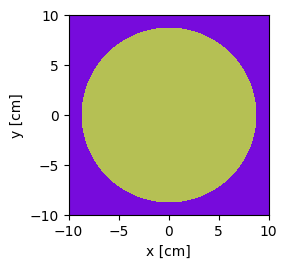

In [4]:
# Define a sphere with a radius of 8.7407 cm
sphere = openmc.Sphere(r=8.7407, boundary_type='vacuum')

# Create a cell: inside the sphere (-sphere) filled with HEU
fuel = openmc.Cell(name='fuel', fill=heu, region=-sphere)

# Create a cell: outside the sphere (+sphere) which is empty
out = openmc.Cell(name='out', region=+sphere)

geometry = openmc.Geometry([fuel, out])
geometry.export_to_xml()

# Visualize the model
geometry.root_universe.plot(origin=(0,0,0), width=(20,20))

## 3. Settings
**Settings** define *how* the simulation is performed. 

* **Particles**: Number of neutrons to track per batch.
* **Batches**: Number of simulation cycles.
* **Inactive**: Initial batches used to let the neutron distribution settle before collecting results.

In [5]:
settings = openmc.Settings()
settings.batches = 100 
settings.inactive = 10 
settings.particles = 1000

settings.export_to_xml()

## 4. Tallies
**Tallies** are like virtual "detectors." While not required to run the code, they are used to measure specific things like:
* Neutron flux
* Reaction rates
* Heating rates
* ...

If you don't define tallies, OpenMC will still calculate the overall multiplication factor ($k_{eff}$).

## 5. Run the Model
Finally, we tell OpenMC to read the XML files and start the Monte Carlo transport simulation.

In [6]:
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

## Appendix

### Neutron Flux Spectrum: The "Hard" Spectrum
The Lady Godiva benchmark is a bare sphere of highly enriched uranium (HEU). Because there is no moderator or reflector, neutrons do not slow down significantly before escaping or causing further fissions.

As shown in the figure below, the energy distribution (flux) peaks near **1 MeV**. This confirms that Godiva is a **fast-spectrum** system, where the physics is dominated by high-energy neutron interactions.

![FLUX](./figures/flux_GODIVA.png)

### Sensitivity Analysis
To understand the physical behavior of the benchmark, we can calculate first-order sensitivity coefficients. A sensitivity coefficient ($S_{k\alpha}$) represents the percentage change in the effective multiplication factor ($k_{eff}$) resulting from a 1% change in a specific nuclear data parameter ($\alpha$):

$$S_{k\alpha} = \frac{\partial k / k}{\partial \alpha / \alpha}$$

The figure below shows these coefficients calculated using the **Serpent-2** Monte Carlo code (utilizing the ECCO-33 multigroup structure). The large sensitivities in the fast energy region (>100 keV) demonstrate which energy ranges are most important for $k_{eff}$.

![SENSITIVITIES](./figures/sensitivities_GODIVA_all.png)

### Uncertainty Quantification (UQ)
We use these sensitivity coefficients to propagate the uncertainties (covariances) found in nuclear data libraries to determine the resulting variance in $k_{eff}$. This is performed using the **Sandwich Formula**:

$$C_{kk} = S^T_{k\alpha} C_{\alpha\alpha} S_{k\alpha}$$

Where:
* $C_{kk}$ is the covariance matrix (or variance) of the output $k_{eff}$.
* $C_{\alpha\alpha}$ is the nuclear data covariance matrix.
* $S_{k\alpha}$ is the vector of sensitivity coefficients.

The table below summarizes the most significant uncertainty contributions. Note that the total uncertainty is the result of propagating the entire covariance matrix (including correlations), not a simple arithmetic sum of the individual components and taking the square root.

| Nuclide | Reaction | Uncertainty contribution (pcm) |
| :--- | :--- | :--- |
| U-235 | all | 1,346.17 |
| U-235 | fiss_capt | 843.27 |
| U-235 | (n,n') | 651.84 |
| U-235 | nubar | 505.31 |
| U-235 | pfns | 332.51 |

<div class="alert alert-block alert-info">
    <p><b> Limitations of the Sandwich Formula</b></p>
    <p>While the Sandwich Formula is the standard "linear" tool for Uncertainty Quantification, it relies on several key assumptions that often do not hold true:</p>
    <ul>
        <li><b>Linearity Assumption:</b> It uses a first-order Taylor series expansion. This approximation fails to capture the true physics for reactions with significant non-linearities or large uncertainties.</li>
        <li><b>Normality Assumption:</b> It assumes that the input nuclear data follows a Gaussian (normal) distribution. However, the true Probability Density Functions (PDFs) are not provided in ENDF-6 formatted tapes; only the first and second moments (mean and covariance) are given.</li>
        <li><b>Boundary Issues:</b> Because it assumes a normal distribution, the formula can mathematically allow for unphysical results (e.g., negative cross-sections) in cases of high relative uncertainty.</li>
    </ul>
    <p>To circumvent these issues, we utilize a <b>sampling-based approach</b> (as we will demonstrate in the remainder of this workshop). By repeatedly sampling the nuclear data files according to the covariance matrix, we can propagate the uncertainties without the need for linear approximations, capturing the full, non-linear impact on the system.</p>
</div>